# Clinical Context

Breast cancer is the most common cancer among women worldwide, affecting about 2.3 million women annually according to the World Health Organization (WHO). This dataset contains features computed from digitized images of fine needle aspirate (FNA) of breast masses. The features describe characteristics of the cell nuclei present in the image.

Understanding these variables is crucial for:

- Computer-aided diagnosis (CAD) systems
- Early detection of malignant tumors
- Reducing unnecessary biopsies
- Supporting clinical decision-making in oncology


# Getting Started

In [18]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('breast_cancer_.csv')

# Display first few rows
print(df.head())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

# Part 1

## Step 1: Shape 

In [2]:
rows_num = df.shape[0]
print("number of rows:", rows_num)
column_num = df.shape[1]
print("number of columns:", column_num)

number of rows: 569
number of columns: 33


**Your Findings:**
- How many rows (observations/patients)? __569__
- How many columns (features)? __33__
- What does each row represent in clinical terms? __Each row represents a patient and their clinical information.__

## Step 2: Column Names

In [3]:
columns = df.columns
column_list = columns.tolist()
print("Column Names:")
for col in column_list:
    index_col = column_list.index(col)+ 1
    print(f' {index_col}. {col}')

Column Names:
 1. id
 2. diagnosis
 3. radius_mean
 4. texture_mean
 5. perimeter_mean
 6. area_mean
 7. smoothness_mean
 8. compactness_mean
 9. concavity_mean
 10. concave points_mean
 11. symmetry_mean
 12. fractal_dimension_mean
 13. radius_se
 14. texture_se
 15. perimeter_se
 16. area_se
 17. smoothness_se
 18. compactness_se
 19. concavity_se
 20. concave points_se
 21. symmetry_se
 22. fractal_dimension_se
 23. radius_worst
 24. texture_worst
 25. perimeter_worst
 26. area_worst
 27. smoothness_worst
 28. compactness_worst
 29. concavity_worst
 30. concave points_worst
 31. symmetry_worst
 32. fractal_dimension_worst
 33. Unnamed: 32


**Your Findings:**
- List all column names: 

- Do you notice any pattern in the column naming convention? __The column names repeat different characteristics of the breast tissue and show that there are different columns to show the mean, standard error, and "worst" values for each characteristic.__
- Which columns might need further research to understand? __The columns that say "worst" will take more research to understand because it is not clear what "worst" means in terms of clinical significance. There is also one unnamed column.__


## Step 3: Data Types

In [4]:
print("Data Types")
print(df.dtypes)

Data Types
id                           int64
diagnosis                      str
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity

**Your Findings:**
- Which columns are numeric (int64 or float64)? __All of the columns except diagnosis are numeric.__

- Which columns are categorical (object/string)? __The diagnosis column is categorical.__

- Are there any data types that seem incorrect? __All the data types seem correct__


## Step 4: First Look

In [5]:
print("First rows:")
df.head()

First rows:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


**Your Findings:**
- What do the actual values look like? __The actual values are mostly numeric integers for each characteristic. The diagnosis is indicated with a single letter for benign or malignant__

- Do you notice anything unusual or unexpected? __Nothing seems too unusual, except the unnamed column__

- What are the possible values for the `diagnosis` column?  __The diagnosis column has 2 possible values: benign (B) or malignant (M)__

## Step 5: Last Look

In [6]:
print("Last rows:")
df.tail()

Last rows:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


**Your Findings:**
- Does the data end cleanly? __Yes, the data ends cleanly__

- Are the last rows consistent with the first rows? __Yes, the last rows are consistent with the first rows__

## Step 6: Memory Usage

In [7]:
memory = df.memory_usage(deep=True).sum()
print(f"Memory usage of dataset: {memory / 1024:.2f} KB")

Memory usage of dataset: 170.16 KB


**Your Findings:**
- How much memory does the dataset use? __170.16__ KB
- Is this a "small" or "large" dataset by data science standards? This is a very small dataset by data science guidelines because it is only 0.17 MB. 


## Step 7: Missing Values

In [8]:
# check columns with missing values
print("Columns with missing values")
print(df.isnull().sum())
# drop columns with missing values
df.dropna(axis=1, how='all')

Columns with missing values
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dim

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


**Your Findings:**
- Which columns have missing values (according to `.isnull()`)? __The column Unamed:32__   

- What percentage of each column is missing? __100% of the Unamed:32 column is missing.__

- ⚠️ **IMPORTANT:** Do you notice any columns that appear to be entirely empty or have suspicious patterns? __The only suspicious column that I noticed is the column Unamed:32 that has null values. I will remove this column from my dataset because it is not a part of the original csv file.__

## Step 8: Duplicates

In [9]:
print(df.duplicated(keep=False).sum())

0


**Your Findings:**
- Are there any duplicate rows? __There are no duplicate rows__
- Are all patient IDs unique? __All patient ids are unique since there are no duplicate rows.__

## Step 9: Basic Statistics 

In [10]:
print(df.describe())


                 id  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  5.690000e+02   569.000000    569.000000      569.000000   569.000000   
mean   3.037183e+07    14.127292     19.289649       91.969033   654.889104   
std    1.250206e+08     3.524049      4.301036       24.298981   351.914129   
min    8.670000e+03     6.981000      9.710000       43.790000   143.500000   
25%    8.692180e+05    11.700000     16.170000       75.170000   420.300000   
50%    9.060240e+05    13.370000     18.840000       86.240000   551.100000   
75%    8.813129e+06    15.780000     21.800000      104.100000   782.700000   
max    9.113205e+08    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813     

**Your Findings:**
- What is the radius_mean range in the dataset? __6.981 to 28.11__
- What is the range of area_mean values? __143.5 to 2501__
- What is the range of concavity_mean values? __0 to 0.4268__
- Do any min/max values seem impossible or clinically unlikely? __The only min/max values that seem clinically unlikely are concavity_mean and concave points_mean because the min values are 0.__

## Step 10: Unique Counts

In [11]:
df.nunique()

id                         569
diagnosis                    2
radius_mean                456
texture_mean               479
perimeter_mean             522
area_mean                  539
smoothness_mean            474
compactness_mean           537
concavity_mean             537
concave points_mean        542
symmetry_mean              432
fractal_dimension_mean     499
radius_se                  540
texture_se                 519
perimeter_se               533
area_se                    528
smoothness_se              547
compactness_se             541
concavity_se               533
concave points_se          507
symmetry_se                498
fractal_dimension_se       545
radius_worst               457
texture_worst              511
perimeter_worst            514
area_worst                 544
smoothness_worst           411
compactness_worst          529
concavity_worst            539
concave points_worst       492
symmetry_worst             500
fractal_dimension_worst    535
Unnamed:

**Your Findings:**
- Which columns have very few unique values (likely categorical)? __The diagnosis column has the fewest unique values (only 2) because this feature is categorical.__

- Which columns have many unique values (likely continuous)? __All the other columns measuring characteristics of the cell nucleus have many unique values because these features are continuous.__ 

- Does the number of unique IDs match the number of rows? __The number of unique IDs does match the number of rows.__


### Part 2: Data Dictionary
Complete the following data dictionary for the **key columns**. For each column, you must:
1. **Research** the clinical meaning
2. **Identify** the feature type (Continuous, Discrete, Categorical-Nominal, Categorical-Ordinal, Binary, Identifier)
3. **Document** the valid values/range you observe
4. **Note** any issues or questions

## Data Dictionary 
| Column | Description | Feature Type | Valid Values/Range | Notes/Issues |
|--------|-------------|--------------|-------------------|--------------|
| `id` |Patient ID number|Identifier|Integer values|Not used for analysis|
| `diagnosis` |Cancer diagnosis | Categorical-Binary |M (Malignant), B (Benign) | |
| `radius_mean` | Mean distance from center to perimeter of nucleus| Continuous|6.98 - 28.11 |Measured in unknown units (likely pixels or μm)|
| `texture_mean` |Standard deviation of gray-scale values |Continuous |9.71-39.3 |larger value = more variation in texture |
| `perimeter_mean` |Mean perimeter of nucleus |Continuous |43.79 - 188.5 | |
| `area_mean` |Mean area of nucleus |Continuous |143.5 - 2501 | |
| `smoothness_mean` |Mean local variation in radius lengths |Continuous |0.053 - 0.163 | |
| `compactness_mean` |Mean of perimeter^2 / area - 1.0 |Continuous |0.019 - 0.345 |Measures shape irregularity |
| `concavity_mean` |Mean severity of concave portions of contour |Continuous |0.0 - 0.427 |Higher = more indentations |
| `concave points_mean` |Mean number of concave portions of contour |Continuous |0.0 - 0.201 | |
| `symmetry_mean` |Mean symmetry of nucleus |Continuous |0.106-0.304| |
| `fractal_dimension_mean` |Mean "coastline approximation" - 1|Continuous |0.050 - 0.097 |Complexity measure |

### Clinical Research Questions for Version D

**1. What is image texture in medical imaging? What does the "texture" feature in this dataset actually measure (standard deviation of gray-scale values)?**

Your answer: Texture in medical imaging refers to the spatial variation of pixel intensities within an image, describing patterns, irregularities, and variations in lightness across image regions. The texture mean in this dataset measures how spread out the brightness values of each pixel in the image are (0=black, 255=white), indicating variation in texture.

---

**2. How are digital images of FNA samples captured and processed? What technology converts a microscope slide into analyzable digital features?**

Your answer: FNA (fine needle aspiration) is an invasive procedure used to collect cell samples from masses in the body. A thin needle is inserted into the lump, and the cells are aspirated and smeared onto a glass slide. This microscopic slide is then stained and protected by a coverslip. A digital pathology scanner and image analysis software convert this slide into a high-resolution digital image file with analyzable features. 

---

**3. What is the relationship between nuclear chromatin patterns (captured by texture) and cancer? Why might malignant cells have different texture patterns?**

Your answer: Nuclear chromatin patterns reflect the organization of DNA and proteins within the nucleus. Irregular and coarse chromatin patterns are an indicator of cancer malignancy. Malignant cells exhibit altered texture patterns compared to normal cells due to underlying genetic and structural changes such as DNA rearrangement, aneuploidy, and dysfunctional gene regulation. 

---

**4. What are the advantages and limitations of using image-derived features for cancer diagnosis compared to traditional histopathology?**

Your answer: Using image-derived features has advantages such as its non-invasiveness, comprehensive assessment of the entire tumor, objective assessment, and detection of patterns invisible to the human eye. Some limitations are a lack of standardization across different institutions, black box algorithms, and technological accessibility. 

---

## Part 3: Data Validation

### 3.1 Diagnosis Distribution Validation 

In [12]:
# Assign Binary Values to Diagnosis Column
df['binary_diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Count patients with malignant (M) tumors
malignant_count = (df['binary_diagnosis'] == 1).sum()
print(f"Patients with Malignant Tumors: {malignant_count}")

# Count patients with benign (B) tumors
benign_count = (df['binary_diagnosis'] == 0).sum()
print(f"Patients with Benign Tumors: {benign_count}")

# # Calculate percentage of each?
print(f"Percentage of Patients with Malignant Tumors: {malignant_count/(malignant_count+benign_count)*100}%")
print(f"Percentage of Patients with Benign Tumors: {benign_count/(malignant_count+benign_count)*100}%")



Patients with Malignant Tumors: 212
Patients with Benign Tumors: 357
Percentage of Patients with Malignant Tumors: 37.258347978910365%
Percentage of Patients with Benign Tumors: 62.741652021089635%


**Your Findings:**

- Is this dataset balanced or imbalanced between the two classes? __This dataset is a bit imbalanced between the two classes, with a higher percentage of patients having benign tumors.__

- In the real world, what percentage of breast biopsies are malignant vs benign? __Approximately 80% of breast biopsies are benign (noncancerous), while about 20% are malignant.__

### 3.2 Empty Column Validation

In [13]:
#Examine empty or null columns
print("Columns with missing values")
print(df.isnull())

Columns with missing values
        id  diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    False      False        False         False           False      False   
1    False      False        False         False           False      False   
2    False      False        False         False           False      False   
3    False      False        False         False           False      False   
4    False      False        False         False           False      False   
..     ...        ...          ...           ...             ...        ...   
564  False      False        False         False           False      False   
565  False      False        False         False           False      False   
566  False      False        False         False           False      False   
567  False      False        False         False           False      False   
568  False      False        False         False           False      False   

     smoothness_mean  c

**Your Findings:**

- Did you find any columns that are entirely empty? __There are no columns that are empty.__

- What should you do with such columns before analysis? __You should drop null columns before analysis so it doesn't interfere with the accuracy of analysis.__

- Why might an empty column exist in a dataset? __An empty column might exist because of errors in data collection or formatting errors with dataset files.__


### 3.3 Feature Range Validation

In [14]:
# Get mean and worst columns
mean_cols = [col for col in df.columns if col.endswith('_mean')]
worst_cols = [col.replace('_mean', '_worst') for col in mean_cols]

# Check if worst >= mean for all features
print("Checking if worst >= mean for each feature:\n")

for mean_col, worst_col in zip(mean_cols, worst_cols):
    if worst_col in df.columns:
        # Check if all worst values are >= mean values
        all_valid = (df[worst_col] >= df[mean_col]).all()
        feature = mean_col.replace('_mean', '')
        
        if all_valid:
            print(f"{feature}: All worst >= mean")
        else:
            violations = (df[worst_col] < df[mean_col]).sum()
            print(f"{feature}: {violations} violations found")

# Overall check
print("\n" + "="*50)
all_features_valid = all(
    (df[worst_col] >= df[mean_col]).all() 
    for mean_col, worst_col in zip(mean_cols, worst_cols) 
    if worst_col in df.columns
)

if all_features_valid:
    print(" All worst values >= mean values")
else:
    print(" Some worst values < mean values")

Checking if worst >= mean for each feature:

radius: All worst >= mean
texture: All worst >= mean
perimeter: All worst >= mean
area: All worst >= mean
smoothness: All worst >= mean
compactness: All worst >= mean
concavity: All worst >= mean
concave points: All worst >= mean
symmetry: All worst >= mean
fractal_dimension: All worst >= mean

 All worst values >= mean values


**Your Findings:**

- Does `radius_worst` always >= `radius_mean`? __Yes, the "worst" measurements are always greater than or equal to the "mean" measurements__ 

- Does this relationship hold for other features? __This relationship still holds for other features.__

- What would it mean if this relationship was violated? __If this relationship was violated, this means there was an error in recording the "worst" measurement.__

## Part 4: Create Texture Variability Groups
Create a new column called `texture_category` that categorizes tumors into clinically-meaningful groups based on `texture_mean` (a measure of gray-scale variation that reflects chromatin patterns).

## Version D: Standard Deviation Based Categories

Use these categories based on the mean and standard deviation of texture_mean:

| Texture Category | Range | Clinical Rationale |
|------------------|-------|-------------------|
| Low | < (mean - 1 SD) | Uniform texture, homogeneous chromatin |
| Below Average | (mean - 1 SD) to mean | Slightly below typical variation |
| Above Average | mean to (mean + 1 SD) | Slightly above typical variation |
| High | (mean + 1 SD) to (mean + 2 SD) | Notable heterogeneity |
| Very High | > (mean + 2 SD) | Extreme variation, often seen in aggressive tumors |


In [15]:
# First, calculate mean and standard deviation
mean = df['texture_mean'].mean() 
std = df['texture_mean'].std()
print(mean)
print(std)

19.289648506151142
4.301035768166949


texture_category
Below Average    215
Above Average    175
Low               91
High              65
Very High         23
Name: count, dtype: int64


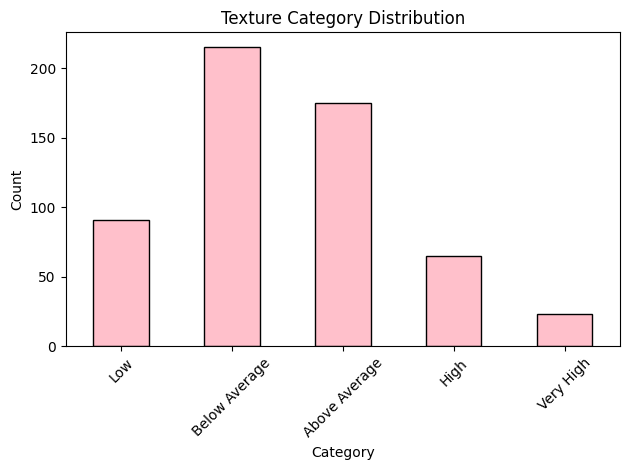

In [21]:
# Define the boundaries based on mean ± SD
bins   = [float('-inf'), mean - std, mean, mean + std, mean + 2*std, float('inf')]
labels = ['Low', 'Below Average', 'Above Average', 'High', 'Very High']

# Create the texture_category column using pd.cut()
df['texture_category'] = pd.cut(df['texture_mean'], bins=bins, labels=labels)

# Verify your groupings worked:
print(df['texture_category'].value_counts())

# Graph results
category_order = ['Low', 'Below Average', 'Above Average', 'High', 'Very High']

counts = df['texture_category'].value_counts().reindex(category_order)

counts.plot(kind='bar', color='pink', edgecolor='black')
plt.title('Texture Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

diagnosis            B     M
texture_category            
Low               95.6   4.4
Below Average     77.7  22.3
Above Average     39.4  60.6
High              33.8  66.2
Very High         52.2  47.8


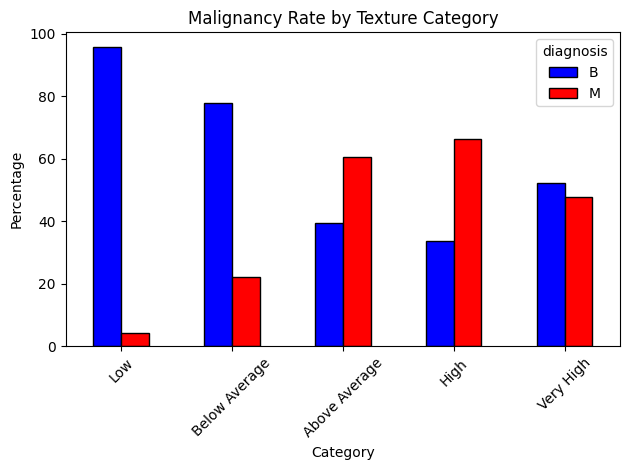

In [26]:
# Calculate malignancy rate by texture category:
malignancy_rate = pd.crosstab(df['texture_category'], df['diagnosis'], normalize='index').round(3) * 100
print(malignancy_rate)

# Graph Results
colors = ['blue', 'red']
malignancy_rate.plot(kind='bar', color= colors, edgecolor='black')
plt.title('Malignancy Rate by Texture Category')
plt.xlabel('Category')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Analysis Questions:

**1. What are the mean and standard deviation values you calculated for texture_mean?**

Your answer: __The mean was 19.29, and the standard deviation was 4.30 for texture_mean__

---

**2. What are the actual boundary values for each category?**

Your answer:
__Low: < 14.99
Below Average: 14.99 – 19.29
Above Average: 19.29 – 23.59
High: 23.59 – 27.89
Very High: > 27.89__

---

**3. How many tumors are in each texture category?**

Your answer: 
__Low: 91
Below Average: 215
Above Average: 175
High: 65
Very High: 23__


---

**4. What is the malignancy rate (percentage) for each texture category? Does higher texture variability appear to be associated with malignancy?**

Your answer:  __The data does show a strong direct relationship between higher texture variability and malignancy, with the "High" texture variability category having the highest malignancy rate.__
__Low: 4.4%
Below Average: 22.3%
Above Average: 60.6%
High: 66.2%
Very High: 47.8%__

---

## Part 5: Research Questions    


### 5.1 Write Three Answerable Questions

1. **Do malignant tumors tend to show a higher perimeter to area ratio compared to benign ones?**
    
---

2. **Is there a strong positive correlation between _worst features and diagnosis of malignancy?**

---

3. **Among tumors with an above-average radius_mean, is there a greater association between texture_mean and malignancy, or does radius alone account for this pattern?**

### 5.2 Identify One Question the Data CANNOT Answer

**Question: Are the high texture_mean values a result of bad image quality?**

**Why it cannot be answered with this data: This question cannot be answered with the data we have because this is just an observational dataset with no experimental control and does not contain explanations for why the dataset has certain values. We could try to answer this question by collecting data with better equipment and image quality, and compare our results.**


### 5.3 Grouping Analysis
**"What is the average texture_mean for each diagnosis category (M vs B)?"**
groupby analysis

In [27]:
# Find mean texture_mean for each diagnosis category 
mean_texture_diagnosis = df.groupby('diagnosis')['texture_mean'].mean().round(2)
print(mean_texture_diagnosis)

diagnosis
B    17.91
M    21.60
Name: texture_mean, dtype: float64


**Your Interpretation:**
How does texture differ between malignant and benign tumors? What might this suggest about the chromatin patterns in cancer cells? __Malignant tumors have an higher average texture_mean than benign tumors. This might indicate that cancer cells have more uneven chromatin patterns than benign cells, creating texture irregularity.__